In [2]:
import numpy as np
import pandas as pd 
dpw = pd.read_csv("C:\\Users\\hp\\OneDrive\\Desktop\\China-Air-pollution-Analysis\\China-Air-pollution-Analysis\\cleaned_pollution_weather.csv")
dcems = pd.read_csv("C:\\Users\\hp\\OneDrive\\Desktop\\China-Air-pollution-Analysis\\China-Air-pollution-Analysis\\cleaned_cems.csv")

In [3]:
dpw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4650 entries, 0 to 4649
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     4650 non-null   object 
 1   provorg  4650 non-null   object 
 2   avg_aqi  4650 non-null   float64
 3   temp     4650 non-null   float64
 4   wdsp     4650 non-null   float64
 5   prcp     4650 non-null   float64
 6   visib    4650 non-null   float64
dtypes: float64(5), object(2)
memory usage: 254.4+ KB


In [4]:
dcems.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169855 entries, 0 to 169854
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   firm_name      169855 non-null  object 
 1   pollutant_x    169855 non-null  object 
 2   time_x         169855 non-null  float64
 3   concentration  169855 non-null  float64
 4   provorg        169855 non-null  object 
 5   dow            169855 non-null  float64
 6   proven         169855 non-null  object 
 7   date           169855 non-null  object 
 8   time_y         169855 non-null  float64
 9   year_x         169855 non-null  float64
 10  nfirms_x       169855 non-null  float64
 11  pollutant_y    169855 non-null  object 
 12  provid_x       169855 non-null  float64
 13  time           169855 non-null  float64
 14  year_y         169855 non-null  float64
 15  nfirms_y       169855 non-null  float64
 16  pollutant      169855 non-null  object 
 17  provid_y       169855 non-nul

In [5]:
dpw["date"] = pd.to_datetime(dpw["date"])
dcems["date"] = pd.to_datetime(dcems["date"])


In [6]:
df_merged = pd.merge(dcems, dpw, on=["date", "provorg"], how="inner")

In [7]:
print(df_merged.isnull().sum())


firm_name        0
pollutant_x      0
time_x           0
concentration    0
provorg          0
dow              0
proven           0
date             0
time_y           0
year_x           0
nfirms_x         0
pollutant_y      0
provid_x         0
time             0
year_y           0
nfirms_y         0
pollutant        0
provid_y         0
avg_aqi          0
temp             0
wdsp             0
prcp             0
visib            0
dtype: int64


In [8]:
df_numeric = df_merged.select_dtypes(include=["number"])

corr_matrix = df_numeric.corr()

print(corr_matrix)


                 time_x  concentration       dow    time_y    year_x  \
time_x         1.000000       0.020856 -0.000762  1.000000  0.065712   
concentration  0.020856       1.000000  0.001463  0.020856 -0.033744   
dow           -0.000762       0.001463  1.000000 -0.000762  0.022557   
time_y         1.000000       0.020856 -0.000762  1.000000  0.065712   
year_x         0.065712      -0.033744  0.022557  0.065712  1.000000   
nfirms_x      -0.030048      -0.044327  0.015436 -0.030048  0.211437   
provid_x      -0.029639      -0.220092 -0.000289 -0.029639  0.091844   
time           1.000000       0.020856 -0.000762  1.000000  0.065712   
year_y         0.065712      -0.033744  0.022557  0.065712  1.000000   
nfirms_y      -0.018828      -0.042072  0.015693 -0.018828  0.211914   
provid_y      -0.029639      -0.220092 -0.000289 -0.029639  0.091844   
avg_aqi       -0.137167       0.074308 -0.025100 -0.137167 -0.138109   
temp          -0.370148      -0.209295  0.002323 -0.370148  0.14

In [9]:
corr_threshold = 0.5 
strong_corr = corr_matrix[abs(corr_matrix) > corr_threshold]
print(strong_corr)


               time_x  concentration  dow  time_y  year_x  nfirms_x  provid_x  \
time_x            1.0            NaN  NaN     1.0     NaN       NaN       NaN   
concentration     NaN            1.0  NaN     NaN     NaN       NaN       NaN   
dow               NaN            NaN  1.0     NaN     NaN       NaN       NaN   
time_y            1.0            NaN  NaN     1.0     NaN       NaN       NaN   
year_x            NaN            NaN  NaN     NaN     1.0       NaN       NaN   
nfirms_x          NaN            NaN  NaN     NaN     NaN  1.000000  0.572219   
provid_x          NaN            NaN  NaN     NaN     NaN  0.572219  1.000000   
time              1.0            NaN  NaN     1.0     NaN       NaN       NaN   
year_y            NaN            NaN  NaN     NaN     1.0       NaN       NaN   
nfirms_y          NaN            NaN  NaN     NaN     NaN  0.999400  0.568463   
provid_y          NaN            NaN  NaN     NaN     NaN  0.572219  1.000000   
avg_aqi           NaN       

In [10]:
#AQI vs. Firm-Level Pollutiond
df_merged[["avg_aqi", "concentration"]].corr()


,avg_aqi,concentration
avg_aqi,1.000000,0.074308
concentration,0.074308,1.000000


In [11]:
#AQI vs. Pollutiond
df_merged[["avg_aqi", "temp", "prcp", "wdsp", "visib"]].corr()


,avg_aqi,temp,prcp,wdsp,visib
avg_aqi,1.000000,-0.169022,-0.494180,-0.058066,0.429846
temp,-0.169022,1.000000,0.499738,0.237921,-0.541923
prcp,-0.494180,0.499738,1.000000,0.391093,-0.735555
wdsp,-0.058066,0.237921,0.391093,1.000000,-0.125739
visib,0.429846,-0.541923,-0.735555,-0.125739,1.000000


In [12]:
#Individual Pollutants vs. AQI
df_merged.groupby("pollutant")["avg_aqi"].mean()


pollutant
SO2    45.469513
Name: avg_aqi, dtype: float64

c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


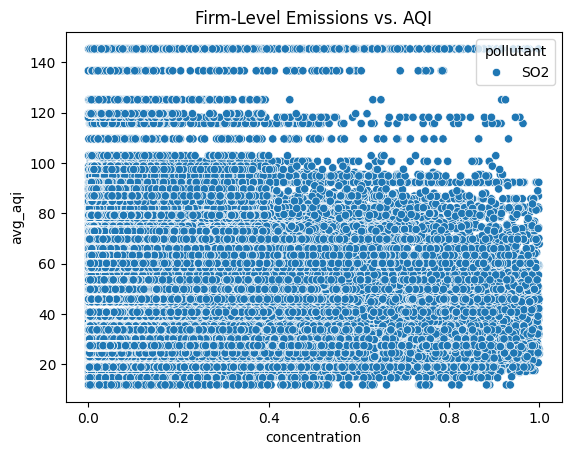

In [14]:
# Concentartion vs AQI 

sns.scatterplot(data=df_merged, x="concentration", y="avg_aqi", hue="pollutant")
plt.title("Firm-Level Emissions vs. AQI")
plt.show()


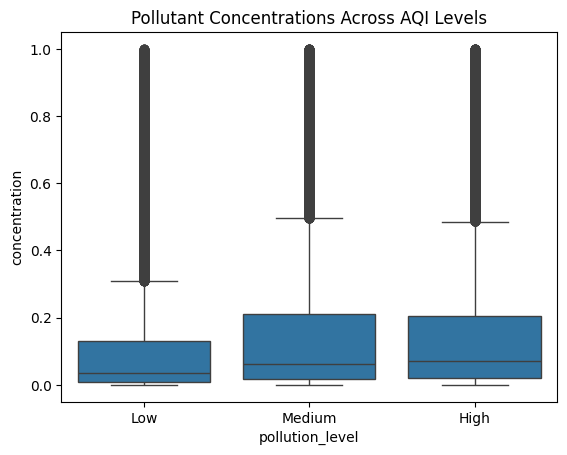

In [15]:
df_merged["pollution_level"] = pd.qcut(df_merged["avg_aqi"], q=3, labels=["Low", "Medium", "High"])
sns.boxplot(data=df_merged, x="pollution_level", y="concentration")
plt.title("Pollutant Concentrations Across AQI Levels")
plt.show()


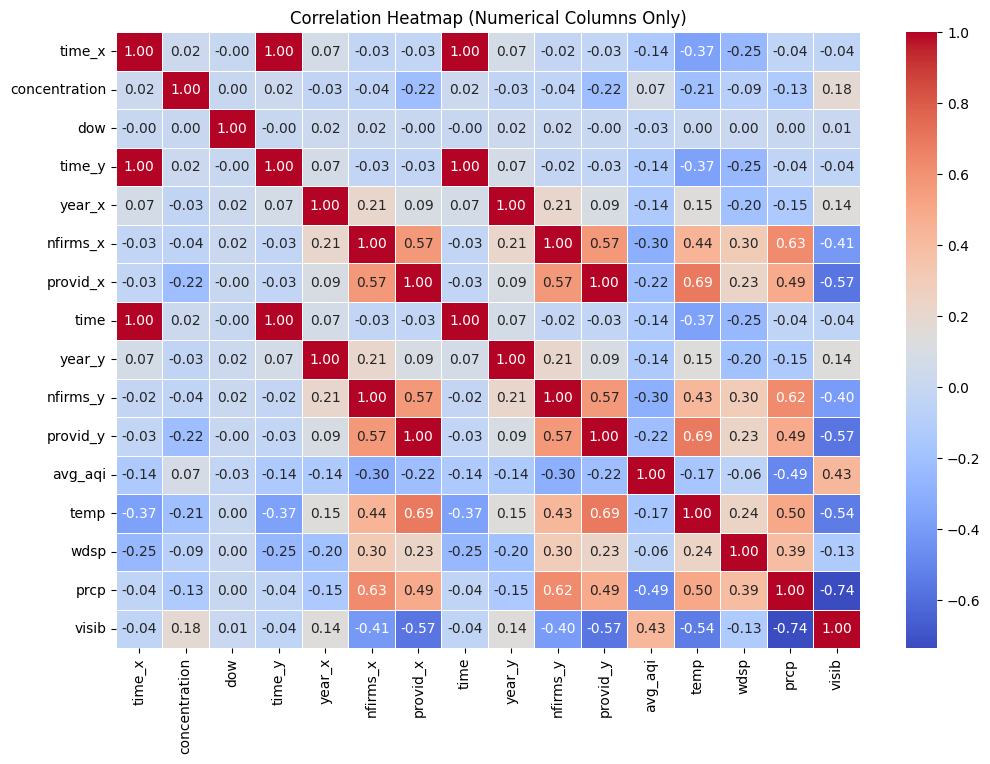

In [16]:
df_numeric = df_merged.select_dtypes(include=['number'])  # Select only numerical columns

# Compute correlation matrix
corr_matrix = df_numeric.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numerical Columns Only)")
plt.show()